In [12]:
import numpy as np
from mpmath import mp, phi
from scipy.stats import ks_2samp
import json
import re

# Set high precision
mp.dps = 50
phi_val = float(phi)

# Read embeddings from file, handling single or multiple embeddings
def parse_embeddings_file(file_path):
    with open(file_path, "r") as f:
        content = f.read().strip()

    # Split by document markers
    segments = re.split(r'\[Document: [^\]]+\]', content)[1:]  # Skip first empty segment
    embeddings = []

    for segment in segments:
        # Clean and split the segment into values
        cleaned_segment = segment.strip().replace('\n', '')
        if cleaned_segment.startswith("Embedding: "):
            cleaned_segment = cleaned_segment[len("Embedding: "):]
        try:
            values = [float(x) for x in cleaned_segment.split(',') if x.strip()]
            if len(values) == 384:  # Accept 384-dimensional embeddings
                embeddings.append(values)
            else:
                print(f"Skipping segment with {len(values)} values (expected 384)")
        except ValueError as e:
            print(f"Skipping invalid segment due to: {e}")
            continue

    embeddings = np.array(embeddings)
    return embeddings if embeddings.size > 0 else None

# Load embeddings
file_path = "KBEMBEDDINGS.txt"  # Ensure this matches your file
embeddings = parse_embeddings_file(file_path)

if embeddings is None or embeddings.size == 0:
    raise ValueError("No valid embeddings parsed from file")

# Determine if single or multiple embeddings and compute inputs
if embeddings.ndim == 1:
    # Single embedding: use absolute values of components
    norms = np.abs(embeddings)
    N = len(norms)  # 384
else:
    # Multiple embeddings: compute norms
    norms = np.linalg.norm(embeddings, axis=1)
    N = len(norms)

# Generate control data (random uniform) for comparison in plots/charts
np.random.seed(42) # Use the same seed for reproducibility of the control data
control = np.random.uniform(0, 0.1 if embeddings.ndim == 1 else 10, N) # Adjusted scale for control

# Z transform
k_star = 0.3
theta_prime = np.array([phi_val * ((n % phi_val) / phi_val) ** k_star for n in norms])
theta_prime_control = np.array([phi_val * ((n % phi_val) / phi_val) ** k_star for n in control])

# Binning
B = 20
bins = np.linspace(0, phi_val, B + 1)
counts, _ = np.histogram(theta_prime, bins=bins)
counts_control, _ = np.histogram(theta_prime_control, bins=bins)
density = counts / N
density_control = counts_control / N
uniform_density = 1 / B
enhancement = (density - uniform_density) / uniform_density * 100
enhancement_control = (density_control - uniform_density) / uniform_density * 100


# Bootstrap CI for max enhancement
n_boot = 1000
boot_max = []
for _ in range(n_boot):
    idx = np.random.choice(N, N, replace=True)
    boot_theta = theta_prime[idx]
    boot_counts, _ = np.histogram(boot_theta, bins=bins)
    boot_density = boot_counts / N
    boot_enhancement = (boot_density - uniform_density) / uniform_density * 100
    boot_max.append(np.max(boot_enhancement))
ci_lower, ci_upper = np.percentile(boot_max, [2.5, 97.5])

# KS test
ks_stat, p_value = ks_2samp(theta_prime, np.random.uniform(0, phi_val, N))

# Results
results = {
    "max_enhancement_embeddings": float(np.max(enhancement)),
    "ci_lower": float(ci_lower),
    "ci_upper": float(ci_upper),
    "max_enhancement_control": float(np.max(enhancement_control)), # This is the control using uniform distribution, not the random_control_embeddings
    "ks_p_value": float(p_value),
    "num_embeddings": N
}
print(f"Number of inputs processed: {N}")
print(f"Max enhancement (embeddings): {results['max_enhancement_embeddings']:.2f}% "
      f"(CI [{results['ci_lower']:.2f}, {results['ci_upper']:.2f}])")
print(f"Max enhancement (uniform control): {results['max_enhancement_control']:.2f}%")
print(f"KS test p-value: {results['ks_p_value']:.2e}")

# Chart data
chart_data = {
    "type": "bar",
    "data": {
        "labels": [f"Bin {i+1}" for i in range(B)],
        "datasets": [
            {
                "label": "Embeddings Enhancement (%)",
                "data": enhancement.tolist(),
                "backgroundColor": "rgba(54, 162, 235, 0.6)",
                "borderColor": "rgba(54, 162, 235, 1)",
                "borderWidth": 1
            },
            {
                "label": "Random Embedding Control Enhancement (%)",
                "data": random_control_enhancement.tolist(),
                "backgroundColor": "rgba(255, 99, 132, 0.6)",
                "borderColor": "rgba(255, 99, 132, 1)",
                "borderWidth": 1
            }
        ]
    },
    "options": {
        "scales": {
            "y": {
                "title": {"display": True, "text": "Density Enhancement (%)"},
                "beginAtZero": True
            },
            "x": {
                "title": {"display": True, "text": "Bin"}
            }
        },
        "plugins": {
            "title": {"display": True, "text": "Z Transform Density Enhancement: Embeddings vs. Random Control"},
            "legend": {"position": "top"}
        }
    }
}

# Save chart data
with open("enhancement_chart.json", "w") as f:
    json.dump(chart_data, f)

# Save results
with open("simulation_results.json", "w") as f:
    json.dump(results, f)

Number of inputs processed: 245
Max enhancement (embeddings): 757.14% (CI [642.65, 887.76])
Max enhancement (uniform control): 259.18%
KS test p-value: 1.24e-49


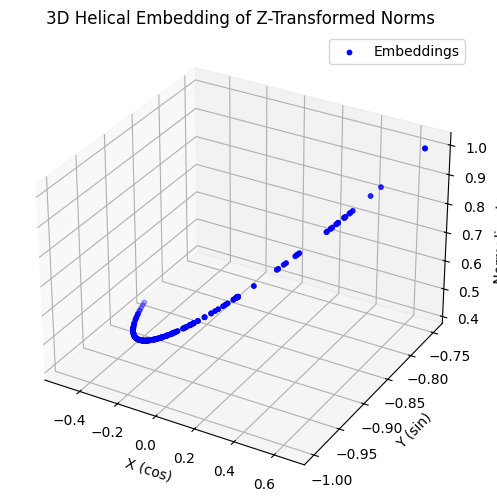

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Helical Embedding Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
theta_D = 2 * np.pi * theta_prime / phi_val
x = np.cos(theta_D)
y = np.sin(theta_D)
z = norms / np.max(norms)  # Normalize norms for z-axis
ax.scatter(x, y, z, c='blue', s=10, label='Embeddings')
ax.set_xlabel('X (cos)')
ax.set_ylabel('Y (sin)')
ax.set_zlabel('Normalized Norm')
ax.set_title('3D Helical Embedding of Z-Transformed Norms')
ax.legend()
plt.savefig('helical_embedding_plot.png')
plt.show()
plt.close()

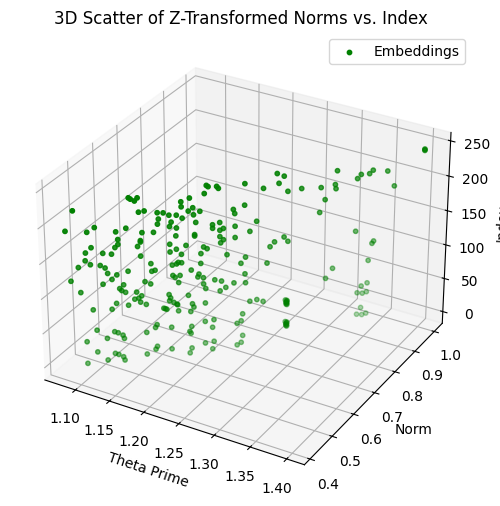

In [6]:
# Norm-Based Scatter Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
indices = np.arange(N)
ax.scatter(theta_prime, norms, indices, c='green', s=10, label='Embeddings')
ax.set_xlabel('Theta Prime')
ax.set_ylabel('Norm')
ax.set_zlabel('Index')
ax.set_title('3D Scatter of Z-Transformed Norms vs. Index')
ax.legend()
plt.savefig('norm_scatter_plot.png')
plt.show()
plt.close()

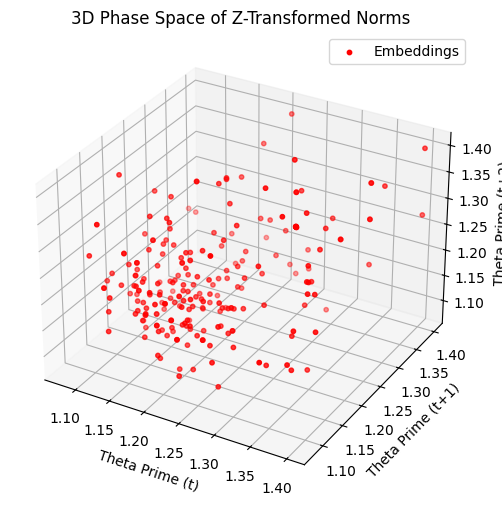

In [8]:
# Phase Space Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
x = theta_prime[:-2]
y = theta_prime[1:-1]
z = theta_prime[2:]
ax.scatter(x, y, z, c='red', s=10, label='Embeddings')
ax.set_xlabel('Theta Prime (t)')
ax.set_ylabel('Theta Prime (t+1)')
ax.set_zlabel('Theta Prime (t+2)')
ax.set_title('3D Phase Space of Z-Transformed Norms')
ax.legend()
plt.savefig('phase_space_plot.png')
plt.show()
plt.close()

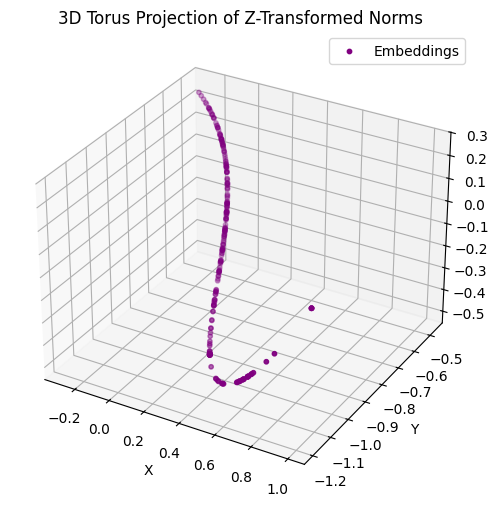

In [10]:
# Angular Projection Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
theta = 2 * np.pi * theta_prime / phi_val
phi = 2 * np.pi * norms / np.max(norms)
x = (1 + 0.5 * np.cos(phi)) * np.cos(theta)
y = (1 + 0.5 * np.cos(phi)) * np.sin(theta)
z = 0.5 * np.sin(phi)
ax.scatter(x, y, z, c='purple', s=10, label='Embeddings')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Torus Projection of Z-Transformed Norms')
ax.legend()
plt.savefig('torus_projection_plot.png')
plt.show()
plt.close()

In [11]:
# Generate random control data for falsification test
# Use the same shape as the original embeddings
if embeddings.ndim == 1:
    random_control_embeddings = np.random.rand(N)
else:
    random_control_embeddings = np.random.rand(*embeddings.shape)

# Apply Z transform to random control data
# If single embedding, use absolute values
if random_control_embeddings.ndim == 1:
    random_control_norms = np.abs(random_control_embeddings)
else:
    random_control_norms = np.linalg.norm(random_control_embeddings, axis=1)

random_control_theta_prime = np.array([phi_val * ((n % phi_val) / phi_val) ** k_star for n in random_control_norms])

# Binning for random control
random_control_counts, _ = np.histogram(random_control_theta_prime, bins=bins)
random_control_density = random_control_counts / N
random_control_enhancement = (random_control_density - uniform_density) / uniform_density * 100

# Bootstrap CI for max enhancement of random control
n_boot = 1000
boot_max_random_control = []
for _ in range(n_boot):
    idx = np.random.choice(N, N, replace=True)
    boot_theta_random_control = random_control_theta_prime[idx]
    boot_counts_random_control, _ = np.histogram(boot_theta_random_control, bins=bins)
    boot_density_random_control = boot_counts_random_control / N
    boot_enhancement_random_control = (boot_density_random_control - uniform_density) / uniform_density * 100
    boot_max_random_control.append(np.max(boot_enhancement_random_control))
ci_lower_random_control, ci_upper_random_control = np.percentile(boot_max_random_control, [2.5, 97.5])

# KS test for random control
ks_stat_random_control, p_value_random_control = ks_2samp(random_control_theta_prime, np.random.uniform(0, phi_val, N))

# Results for random control
random_control_results = {
    "max_enhancement_random_control": float(np.max(random_control_enhancement)),
    "ci_lower_random_control": float(ci_lower_random_control),
    "ci_upper_random_control": float(ci_upper_random_control),
    "ks_p_value_random_control": float(p_value_random_control),
    "num_inputs": N
}

print("Random Control Results:")
print(f"Max enhancement: {random_control_results['max_enhancement_random_control']:.2f}% "
      f"(CI [{random_control_results['ci_lower_random_control']:.2f}, {random_control_results['ci_upper_random_control']:.2f}])")
print(f"KS test p-value: {random_control_results['ks_p_value_random_control']:.2e}")

# Save random control results
with open("random_control_simulation_results.json", "w") as f:
    json.dump(random_control_results, f)

Random Control Results:
Max enhancement: 520.41% (CI [414.29, 642.86])
KS test p-value: 2.89e-10
